[1.84059857 2.84196669 5.44464892]
[1.84059857 2.84196669 5.44464892]


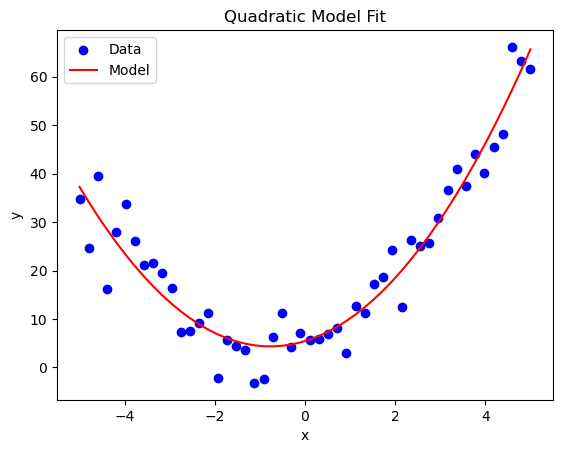

In [ ]:
# ===========================================================
# 🧩 Problem 1 — Quadratic Model Plot Fix
# ===========================================================
"""
You are given a code cell that correctly calculates the coefficients of a
quadratic model (y_i ≈ a·x_i^2 + b·x_i + c) between two variables.
The model code cell is correct.

In the next code cell, a scatter plot of the individual data and a line plot
of the model prediction is generated, but the plot is obviously wrong.

Make the necessary modifications to generate a correct plot.
"""

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# sample data
x = np.linspace(-5, 5, 50)#make 50 points between -5 to 5
y = 2 * x**2 + 3 * x + 5 + np.random.randn(50) * 5 #this np.random.randn(50) adds noise


# fit quadratic model
coeffs = np.polyfit(x, y, 2)
print(coeffs)
a, b, c = coeffs
print(coeffs)


# predicted values
y_pred = a * x**2 + b * x + c

# ✅ Correct plotting (sort x before plotting line)
plt.scatter(x, y, color="blue", label="Data")
plt.plot(x, y_pred, color="red", label="Model")
#plt.plot(np.sort(x), y_pred[np.argsort(x)], color="red", label="Model")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Quadratic Model Fit")
plt.legend()
plt.show()

# 🔸Notes:
# - ax.show() is invalid; only plt.show() works.
# - Always sort x when plotting model lines to avoid zigzag plots.



[2.12812334 2.88323701 3.61249768]
[2.12812334 2.88323701 3.61249768]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]


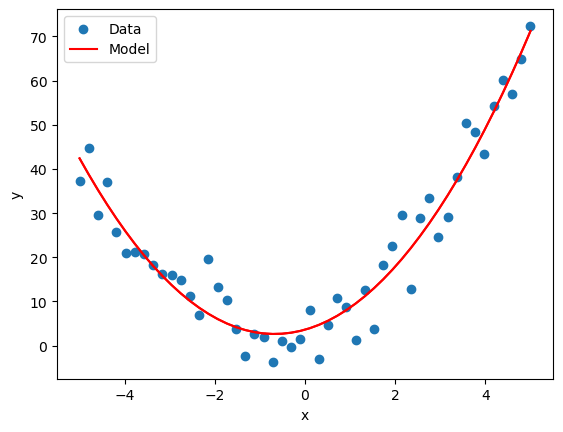

In [8]:
# assume we already have x, y, a, b, c
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# sample data
x = np.linspace(-5, 5, 50)#make 50 points between -5 to 5
y = 2 * x**2 + 3 * x + 5 + np.random.randn(50) * 5 #this np.random.randn(50) adds noise


# fit quadratic model
coeffs = np.polyfit(x, y, 2)
print(coeffs)
a, b, c = coeffs
print(coeffs)

# Create model predictions
y_pred = a * x**2 + b * x + c

# Plot scatter of data + line of model
plt.scatter(x, y, label="Data")

#Sort values using
idx = np.argsort(x)
print(idx)
plt.plot(x[idx], y_pred[idx], 'r')


#OR
#df = pd.DataFrame({"x": x, "y": y, "y_pred": y_pred}).sort_values(by="x")
#plt.scatter(df["x"], df["y"])
#plt.plot(df["x"], df["y_pred"], color="red")
#plt.show()





plt.plot(x, y_pred, color="red", label="Model")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()


<Axes: xlabel='date'>

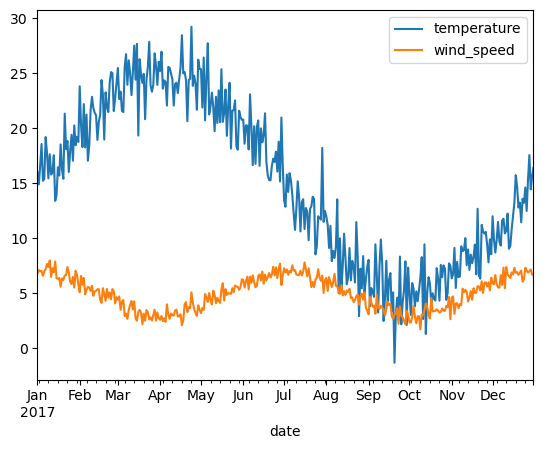

In [62]:


# ===========================================================
# 🧩 Problem 2 — Delhi Weather Data Plot
# ===========================================================
"""
Read in a .csv file containing weather data for Delhi, India (2017).
Using the ".plot()" method connected to a Pandas DataFrame (not matplotlib.pyplot),
generate a single line plot with (time vs. temperature) and (time vs. wind speed).
"""

dl = pd.read_csv("delhi_weather_2017.csv")
dl["date"] = pd.to_datetime(dl["date"], format="%Y-%m-%d")


#dl.plot(x="date", y=["temperature", "wind_speed"], title="Delhi Weather 2017")
#plt.show()


dl[   ["date","temperature","wind_speed"]   ].set_index("date").plot()






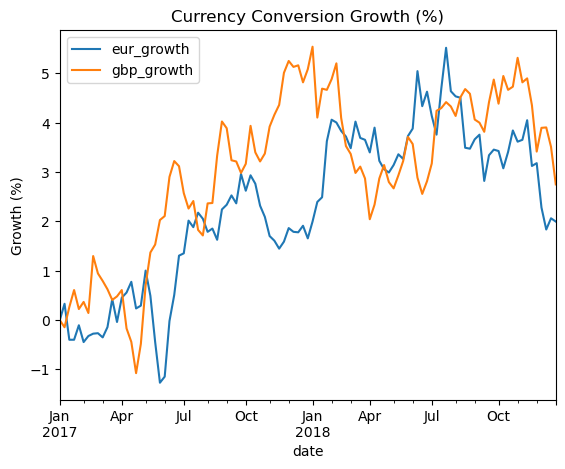

In [ ]:

# ===========================================================
# 🧩 Problem 3 — Currency Conversion Growth
# ===========================================================
"""
Read in a .csv file containing conversion rates for Euros to U.S. dollars and
British Pounds to U.S. dollars over time.
Compute non-dimensional percentage growth values for each and plot both on
a single figure. (You can use either matplotlib.pyplot or the Pandas .plot() method.)
"""

df_conv = pd.read_csv("currency_conversion.csv")
df_conv["date"] = pd.to_datetime(df_conv["date"])

# percentage growth (normalized)
df_conv["eur_growth"] = (df_conv["EUR_USD"] / df_conv["EUR_USD"].iloc[0] - 1) * 100
df_conv["gbp_growth"] = (df_conv["GBP_USD"] / df_conv["GBP_USD"].iloc[0] - 1) * 100


df_conv[   ["date", "eur_growth", "gbp_growth" ]    ].set_index("date").plot()
plt.title("Currency Conversion Growth (%)")
plt.ylabel("Growth (%)")
plt.show()


# 🔸Notes:
# - Non-dimensional growth = (value / initial_value - 1) * 100
# - Using .iloc[0] ensures normalization starts at the first date.




In [23]:
display(df_conv)

,date,EUR_USD,GBP_USD,eur_growth,gbp_growth,eur_high
0,2017-01-01,1.0567,1.2476,0.000000,0.000000,False
1,2017-01-08,1.0602,1.2458,0.331220,-0.144277,False
2,2017-01-15,1.0525,1.2509,-0.397464,0.264508,False
3,2017-01-22,1.0525,1.2552,-0.397464,0.609170,False
4,2017-01-29,1.0556,1.2504,-0.104098,0.224431,False
...,...,...,...,...,...,...
100,2018-12-02,1.0903,1.2902,3.179710,3.414556,False
101,2018-12-09,1.0808,1.2962,2.280685,3.895479,False
102,2018-12-16,1.0761,1.2963,1.835904,3.903495,False
103,2018-12-23,1.0785,1.2914,2.063026,3.510741,False


In [67]:

# ===========================================================
# 🧩 Problem 4 — Boolean Column for Conversion Rate
# ===========================================================
"""
Continuing with the same DataFrame of conversion rates,
create a new column of Boolean type, which checks whether the
Euro conversion rate was greater than a given value (e.g., 1.2).
"""

threshold = 1.1
df_conv["eur_high"] = df_conv["EUR_USD"] > threshold
display(df_conv[["date", "EUR_USD", "eur_high"]])


# 🔸Notes:
# - The Boolean column stores True/False values.
# - Can be used directly for masking or conditional highlighting.




,date,EUR_USD,eur_high
0,2017-01-01,1.0567,False
1,2017-01-08,1.0602,False
2,2017-01-15,1.0525,False
3,2017-01-22,1.0525,False
4,2017-01-29,1.0556,False
...,...,...,...
100,2018-12-02,1.0903,False
101,2018-12-09,1.0808,False
102,2018-12-16,1.0761,False
103,2018-12-23,1.0785,False


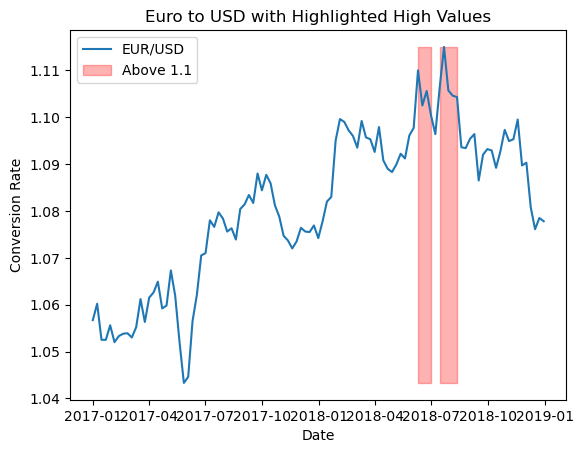

In [38]:

# ===========================================================
# 🧩 Problem 5 — Highlight High Conversion Regions
# ===========================================================
"""
Continuing from Problem 4,
make a line plot of the conversion rate for this currency
and highlight regions where the conversion rate is larger than
the given value using "plt.fill_between".
"""

plt.plot(df_conv["date"], df_conv["EUR_USD"], label="EUR/USD")


plt.fill_between(x = df_conv["date"],
                 y1 = df_conv["EUR_USD"].min(),
                 y2 = df_conv["EUR_USD"].max(),
                 where = df_conv["eur_high"],
                 color = "red",
                 alpha = 0.3,
                 label = "Above 1.1")


plt.xlabel("Date")
plt.ylabel("Conversion Rate")
plt.title("Euro to USD with Highlighted High Values")
plt.legend()
plt.show()

# 🔸Notes:
# - plt.fill_between() shades the region between the curve and threshold.
# - "where" argument takes a Boolean array (True = region to fill).




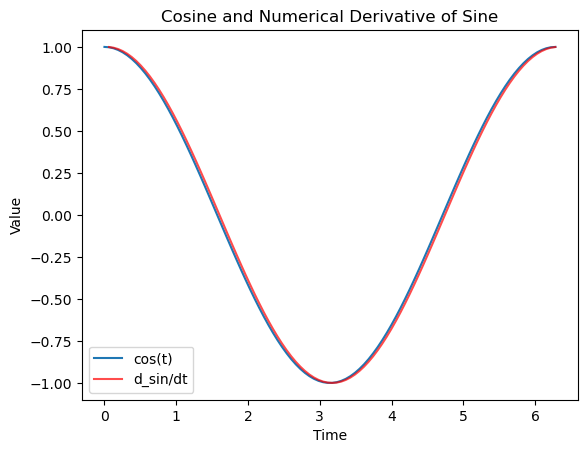

In [68]:

# ===========================================================
# 🧩 Problem 6 — Sine Derivative Approximation
# ===========================================================
"""
Create a DataFrame with columns:
  time: evenly spaced values between 0 and 2π
  sin: sin(time)
  cos: cos(time)

Using the ".diff()" method, create a new column called "d_sin_dt" with:
  d_sin_dt = (sin(t_{k+1}) - sin(t_k)) / (t_{k+1} - t_k)

Plot (time vs. cos) and (time vs. d_sin_dt) together on a single figure.

From calculus, this should be close to cos(t).
"""

time = np.linspace(0, 2 * np.pi, 100)

df = pd.DataFrame({
    "time": time,
    "sin": np.sin(time),
    "cos": np.cos(time)
})  

df["d_sin_dt"] =  df["sin"].diff() / df["time"].diff()

plt.plot("time", "cos", data=df)
plt.plot("time", "d_sin_dt", data=df, alpha = 0.7, color = "red")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend(["cos(t)", "d_sin/dt"])
plt.title("Cosine and Numerical Derivative of Sine")
plt.show()


# 🔸Notes:
# - The first value of d_sin_dt will be NaN because diff() has no previous element.
# - This demonstrates that d/dt(sin(t)) ≈ cos(t) numerically.


